**Supply Chain Optimization & Demand Forecasting System**

In [4]:
import kagglehub
path = kagglehub.dataset_download("saurabhbadole/walmart-super-market-dataset")

100%|██████████| 3.62M/3.62M [00:00<00:00, 4.18MB/s]

Extracting files...


In [5]:
import os

print(os.listdir(path))

['Master Data']


In [6]:
print(os.listdir(path + "/Master Data"))

['train.csv', 'sampleSubmission.csv', 'test.csv', 'stores.csv', 'features.csv']


In [7]:
import pandas as pd

df = pd.read_csv(path + "/Master Data/train.csv")
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [8]:
print(df.shape)
print(df.columns)

(421570, 5)
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')


In [9]:
# Convert Date to proper format
df['Date'] = pd.to_datetime(df['Date'])

# Create new useful columns
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Check missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

df.head()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Month           0
Year            0
dtype: int64


,Store,Dept,Date,Weekly_Sales,IsHoliday,Month,Year
0,1,1,2010-02-05,24924.50,False,2,2010
1,1,1,2010-02-12,46039.49,True,2,2010
2,1,1,2010-02-19,41595.55,False,2,2010
3,1,1,2010-02-26,19403.54,False,2,2010
4,1,1,2010-03-05,21827.90,False,3,2010


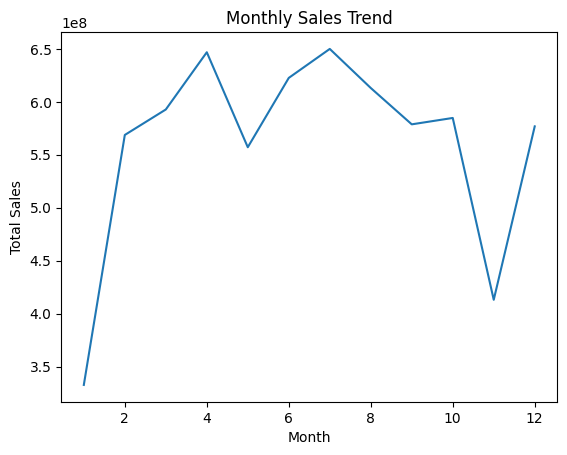

In [10]:
import matplotlib.pyplot as plt

monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [11]:
#Holiday analysis

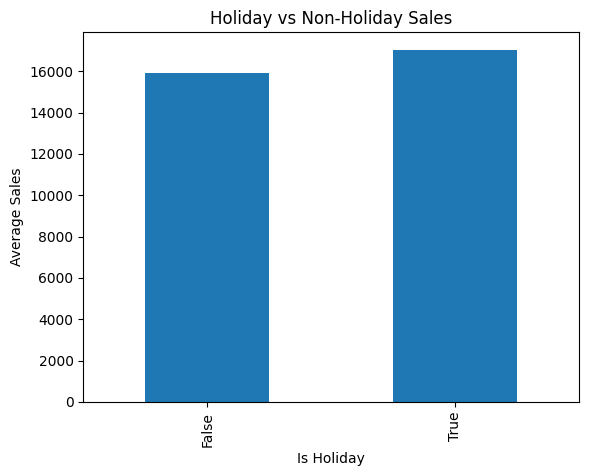

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


In [12]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

holiday_sales.plot(kind='bar')
plt.title("Holiday vs Non-Holiday Sales")
plt.xlabel("Is Holiday")
plt.ylabel("Average Sales")
plt.show()

print(holiday_sales)

In [13]:
#demand prediction ML model


In [15]:
#preparing data
# Features (inputs)
X = df[['Store', 'Dept', 'Month', 'Year', 'IsHoliday']]

# Convert True/False to 1/0
X['IsHoliday'] = X['IsHoliday'].astype(int)

# Target (output)
y = df['Weekly_Sales']

/tmp/ipykernel_4711/880957405.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['IsHoliday'] = X['IsHoliday'].astype(int)


In [16]:
#training model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestRegressor(n_estimators=50)

# Train
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=50)

In [17]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)

error = mean_absolute_error(y_test, predictions)

print("MAE:", error)

MAE: 1793.8294733617852


In [19]:
# Sort data by time
df = df.sort_values('Date')

# Split based on year
train = df[df['Year'] < 2012]
test = df[df['Year'] >= 2012]

# Features
X_train = train[['Store', 'Dept', 'Month', 'Year', 'IsHoliday']]
X_test = test[['Store', 'Dept', 'Month', 'Year', 'IsHoliday']]

X_train = X_train.copy()
X_test = X_test.copy()

X_train['IsHoliday'] = X_train['IsHoliday'].astype(int)
X_test['IsHoliday'] = X_test['IsHoliday'].astype(int)

# Target
y_train = train['Weekly_Sales']
y_test = test['Weekly_Sales']

print(X_train.shape, X_test.shape)

(294132, 5) (127438, 5)


In [21]:
#training

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, max_depth=10)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10)

In [22]:
#evaluate

from sklearn.metrics import mean_absolute_error, r2_score

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 5665.368145316291
R2 Score: 0.8102085528320048


In [24]:
#lag
df = df.sort_values(['Store', 'Dept', 'Date'])

df['Lag_1'] = df.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)

df = df.dropna()

In [25]:
# Recreate Month & Year (in case needed)
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Split again (time-based)
train = df[df['Year'] < 2012]
test = df[df['Year'] >= 2012]

# Features (NOW including Lag)
X_train = train[['Store', 'Dept', 'Month', 'Year', 'IsHoliday', 'Lag_1']]
X_test = test[['Store', 'Dept', 'Month', 'Year', 'IsHoliday', 'Lag_1']]

# Fix warning
X_train = X_train.copy()
X_test = X_test.copy()

X_train['IsHoliday'] = X_train['IsHoliday'].astype(int)
X_test['IsHoliday'] = X_test['IsHoliday'].astype(int)

# Target
y_train = train['Weekly_Sales']
y_test = test['Weekly_Sales']

print(X_train.shape, X_test.shape)

(287567, 6) (127378, 6)


In [26]:
#train with lag
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, max_depth=10)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=10)

In [27]:
#evaluate with lag
from sklearn.metrics import mean_absolute_error, r2_score

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 1715.5054416442522
R2 Score: 0.9691793369758686


In [28]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

In [29]:
#DONE


In [30]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>